In [1]:
import sqlite3

In [2]:
conn = sqlite3.connect("nifty50.db")
cursor = conn.cursor()
cursor.execute("""SELECT * FROM messages""")
results = cursor.fetchall()

In [3]:
import pandas as pd
from ast import literal_eval

In [13]:
result_df = pd.DataFrame(results)
market_data = pd.json_normalize(
    result_df[3].apply(lambda x: literal_eval(x))
)

In [14]:
market_data.time = pd.to_datetime(market_data.time, unit="ms")
print(market_data.shape)
market_data = market_data.drop_duplicates().reset_index(drop=True) # Delete duplicates

C:\Users\sagar\AppData\Local\Temp\ipykernel_331924\2639955639.py:1: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  market_data.time = pd.to_datetime(market_data.time, unit="ms")


(21684, 13)


`id`: Identifier for the financial instrument.

`^NSEI` refers to the NIFTY 50 index on the National Stock Exchange of India. 

`price`: Current market price of the index. Here, 25,867.30 INR.

`time`: Timestamp of the data in epoch milliseconds. 1770631266000 corresponds to February 9, 2026, 18:01:06 UTC.

`exchange`: The stock exchange. NSI refers to the National Stock Exchange (NSE) of India.

`quote_type`: Indicates the type of quote. A value of 9 typically represents an index in financial APIs.

`market_hours`: Indicates if the market is open. 1 means regular market hours.

`change_percent`: Percentage change from the previous close. Here, +0.676%.

`change`: Absolute change in points from the previous close. Here, +173.60 points.

`price_hint`: Suggests how to format the price. '2' means the price should be displayed with 2 decimal places. 

## Data visualization

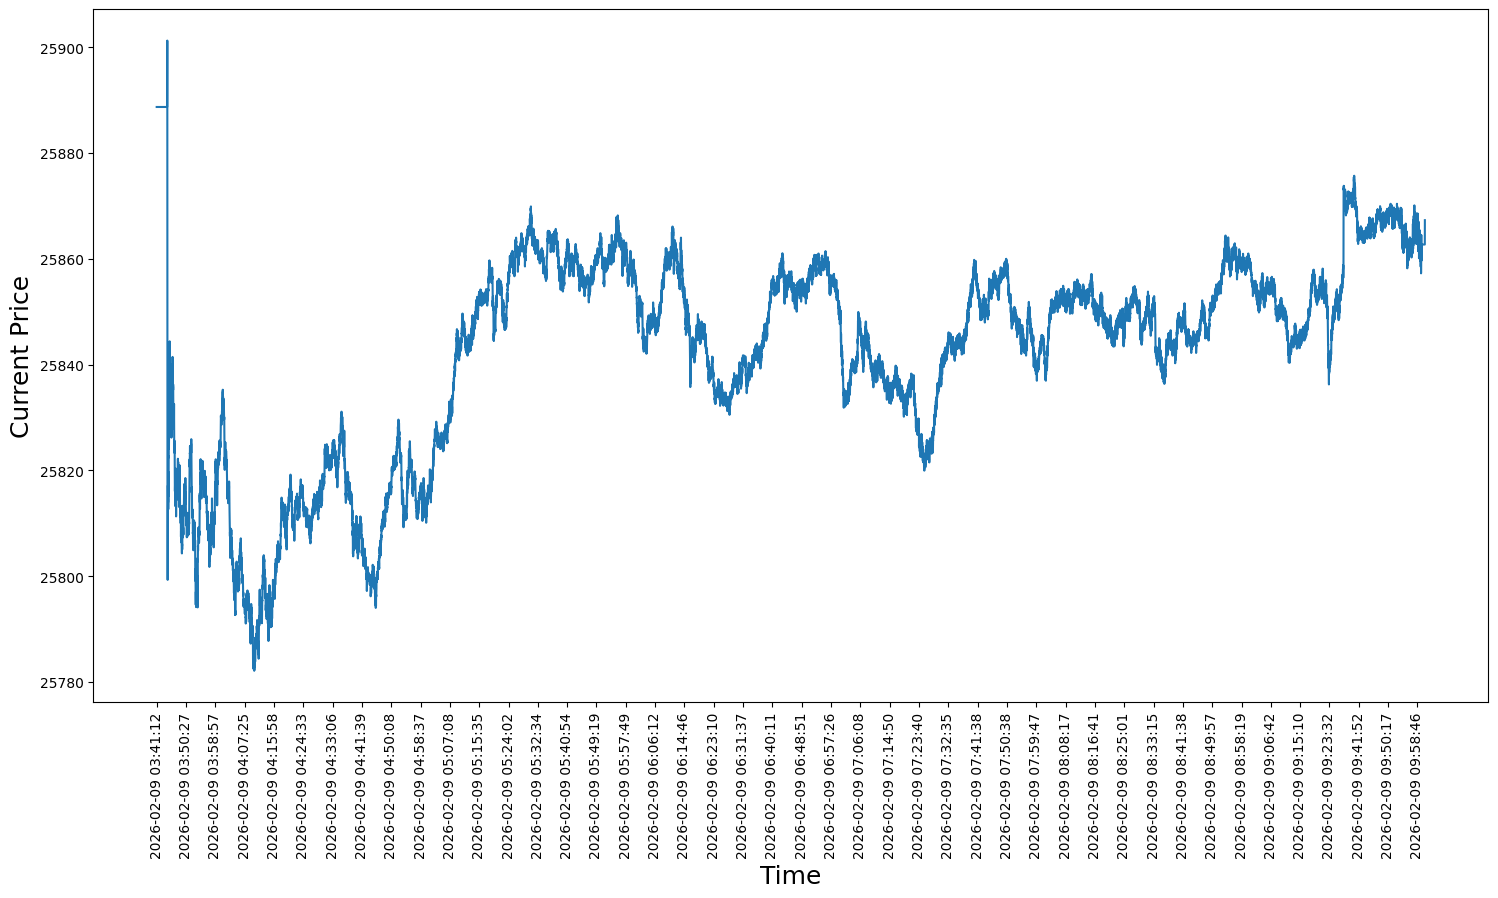

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize = (18,9))
plt.plot(market_data.index, market_data.price)
plt.xticks(range(0, market_data.shape[0], 500), market_data.loc[::500, "time"] ,rotation=90)
plt.xlabel('Time',fontsize=18)
plt.ylabel('Current Price',fontsize=18)
plt.show()


## Splitting Data Into a Training Set and a Test Set

In [20]:
test_percentage = 0.2
split_index = int(market_data.shape[0] * test_percentage)
train_data = market_data.loc[:split_index, "price"].to_numpy()
test_data = market_data.loc[split_index:, "price"].to_numpy()

## Normalizing the Data

In [21]:
# Scale the data to be between 0 and 1
# When scaling remember! You normalize both test and train data with respect to training data
# Because you are not supposed to have access to test data
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
train_data = train_data.reshape(-1,1)
test_data = test_data.reshape(-1,1)

In [22]:
# Train the Scaler with training data and smooth data
smoothing_window_size = 250

for di in range(0, train_data.shape[0], smoothing_window_size):
    scaler.fit(train_data[di:di+smoothing_window_size,:])
    train_data[di:di+smoothing_window_size,:] = scaler.transform(train_data[di:di+smoothing_window_size,:])

train_data = train_data.reshape(-1)


In [23]:
for di in range(0, test_data.shape[0], smoothing_window_size):
    scaler.fit(test_data[di:di+smoothing_window_size,:])
    test_data[di:di+smoothing_window_size,:] = scaler.transform(test_data[di:di+smoothing_window_size,:])

test_data = test_data.reshape(-1)


## Standard average

In [24]:
market_data

,id,price,time,exchange,quote_type,market_hours,change_percent,change,price_hint,day_high,day_low,open_price,currency
0,^NSEI,0.8769,2026-02-09 03:41:12,NSI,9,1,0.958937,245.89844,2,NaN,NaN,NaN,NaN
1,^NSEI,0.8769,2026-02-09 03:41:13,NSI,9,1,0.958937,245.89844,2,NaN,NaN,NaN,NaN
2,^NSEI,0.8769,2026-02-09 03:41:14,NSI,9,1,0.958937,245.89844,2,NaN,NaN,NaN,NaN
3,^NSEI,0.8769,2026-02-09 03:41:15,NSI,9,1,0.958937,245.89844,2,NaN,NaN,NaN,NaN
4,^NSEI,0.8769,2026-02-09 03:41:16,NSI,9,1,0.958937,245.89844,2,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21623,^NSEI,0.0000,2026-02-09 10:01:00,NSI,9,1,0.657749,169.00000,2,NaN,NaN,NaN,NaN
21624,^NSEI,0.0000,2026-02-09 10:01:01,NSI,9,1,0.657749,169.00000,2,NaN,NaN,NaN,NaN
21625,^NSEI,0.0000,2026-02-09 10:01:03,NSI,9,1,0.657749,169.00000,2,NaN,NaN,NaN,NaN
21626,^NSEI,0.0000,2026-02-09 10:01:04,NSI,9,1,0.657749,169.00000,2,NaN,NaN,NaN,NaN


In [25]:
import datetime as dt
window_size = 100
N = train_data.size
std_avg_predictions = []
std_avg_x = []
mse_errors = []

for pred_idx in range(window_size, N):
    date = market_data.loc[pred_idx,'time']
    std_avg_predictions.append(np.mean(train_data[pred_idx-window_size:pred_idx]))
    mse_errors.append((std_avg_predictions[-1]-train_data[pred_idx])**2)
    std_avg_x.append(date)

print('MSE error for standard averaging: %.5f'%(0.5*np.mean(mse_errors)))


MSE error for standard averaging: 0.03184


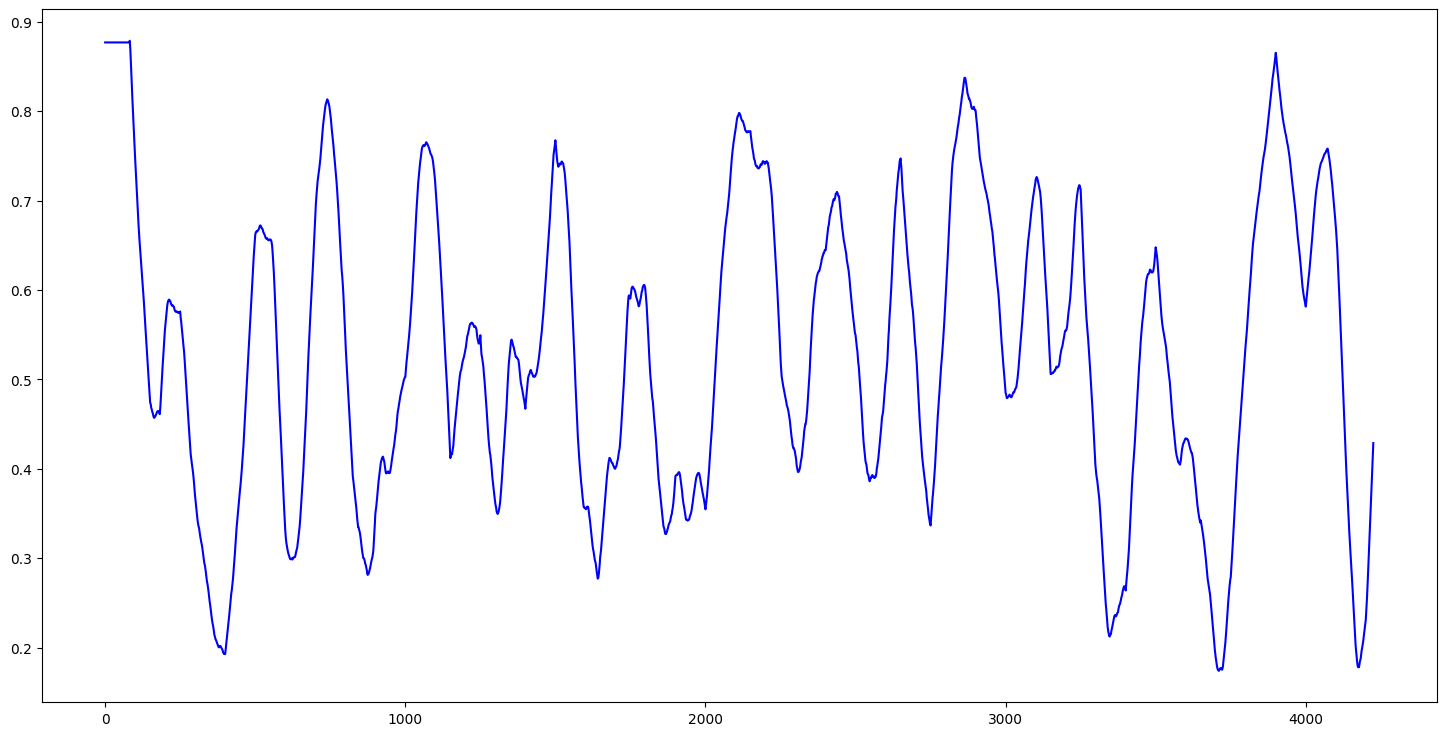

In [ ]:
plt.figure(figsize = (18,9))
plt.plot(range(len(std_avg_predictions)),std_avg_predictions,color='b',label='True')
plt.show()

## Exponential moving average

In [29]:
window_size = 100
N = train_data.size

run_avg_predictions = []
run_avg_x = []

mse_errors = []

running_mean = 0.0
run_avg_predictions.append(running_mean)

decay = 0.5

for pred_idx in range(1,N):

    running_mean = running_mean*decay + (1.0-decay)*train_data[pred_idx-1]
    run_avg_predictions.append(running_mean)
    mse_errors.append((run_avg_predictions[-1]-train_data[pred_idx])**2)
    run_avg_x.append(date)

print('MSE error for EMA averaging: %.5f'%(0.5*np.mean(mse_errors)))


MSE error for EMA averaging: 0.00233


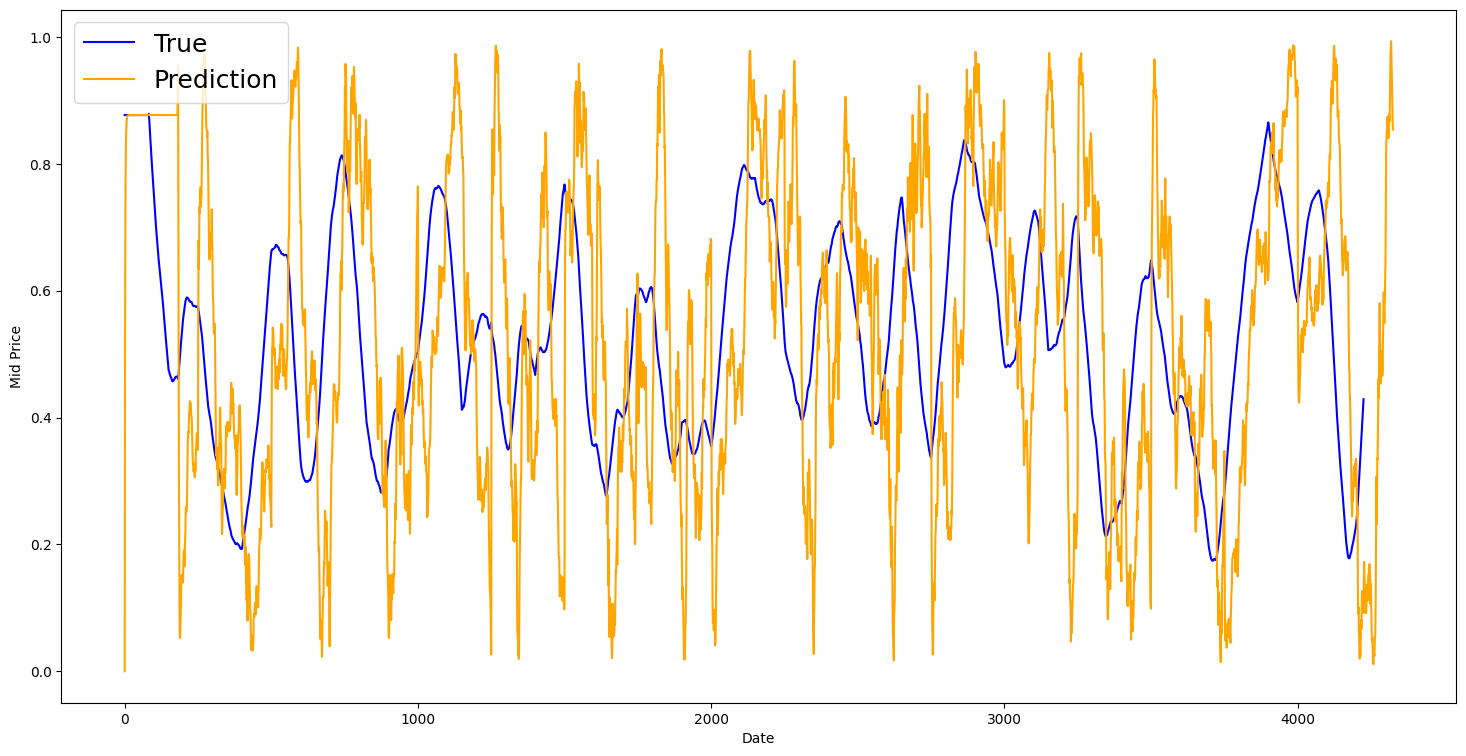

In [33]:
plt.figure(figsize = (18,9))
plt.plot(range(len(std_avg_predictions)), std_avg_predictions, color='b',label='True')
plt.plot(range(len(run_avg_predictions)),run_avg_predictions,color='orange', label='Prediction')
# plt.xticks(range(0,df.shape[0],50),df['Date'].loc[::50],rotation=45)
plt.xlabel('Date')
plt.ylabel('Mid Price')
plt.legend(fontsize=18)
plt.show()
